# Exercise - Multiple Linear Regression



It's time for you to apply your knowledge to a new dataset. So that not too much changes come at once, we will stick to the cars topic and work with the **car seats data**. A company that makes car seats would like to construct a model to predict sales and they need your help!

You will find the file called `carseats.csv` in the data folder. It contains 400 observations on the following 11 variables:
* **Sales**:         Unit sales (in thousands) at each location
* **CompPrice**:     Price charged by competitor at each location
* **Income**:        Community income level (in thousands of dollars)
* **Advertising**:   Local advertising budget for company at each location (in thousands of dollars)
* **Population**:    Population size in region (in thousands)
* **Price**:         Price company charges for car seats at each site
* **ShelveLoc**:     A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site
* **Age**:           Average age of the local population
* **Education**:     Education level at each location
* **Urban**:         A factor with levels No and Yes to indicate whether the store is in an urban or rural location
* **US**:            A factor with levels No and Yes to indicate whether the store is in the US or not

**(a) Load the data**

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# Set figure stile and size for entire notebook
sns.set_style("ticks")
plt.rcParams["figure.figsize"] = (7, 4)

In [3]:
df = pd.read_csv("./data/carseats.csv")
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


**(b) Visualize the data with the appropriate plots.** 

<br>
<details><summary>
Click here for a hint…
</summary>
Check the documentation for seaborn's pair plots. 
</details>

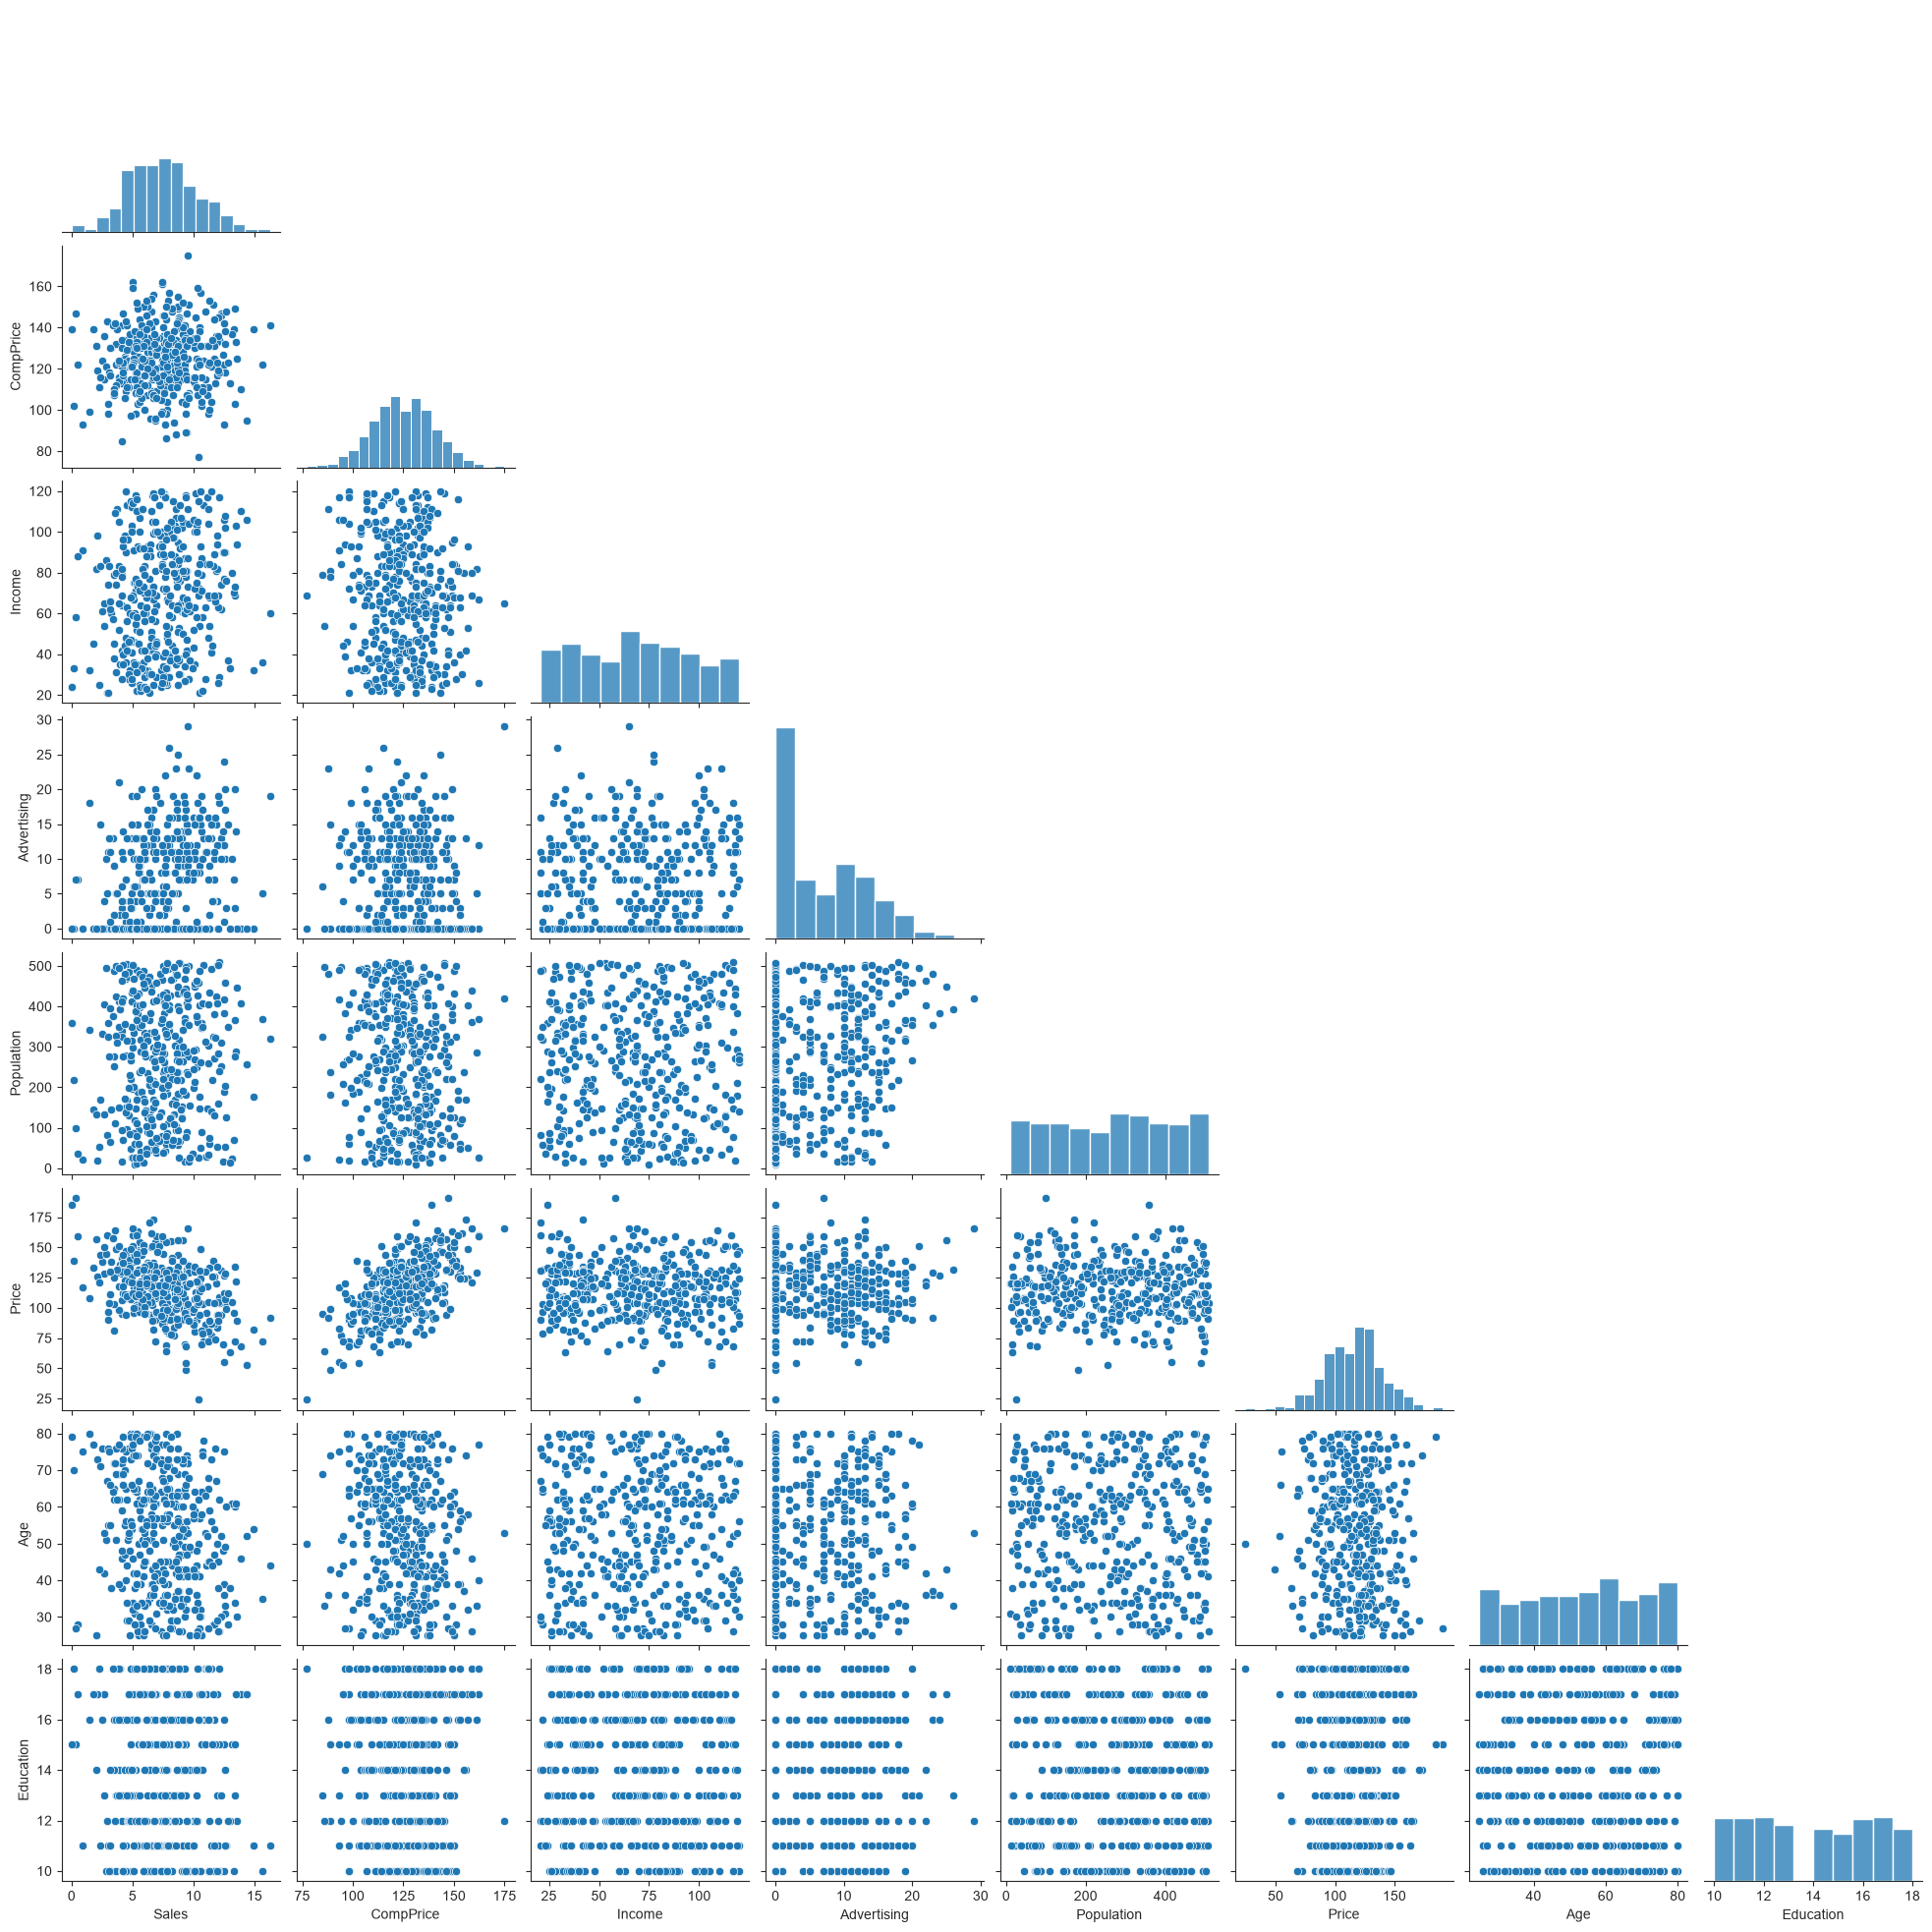

In [4]:
sns.pairplot(df, corner=True);

**(c) What trends do you see in the data?**

The only clear trend observed is the one between Sales and Price, showing a negative correlation. Other variables show weak or no clear linear relationships with Sales.

**(d) Find the single best predictor for a simple linear regression.**

<br>
<details><summary>
Click here for a hint…
</summary>
Fit a linear model to all possible explanatory variables and pick best one.
</details>

In [6]:
X_1 = df[["Price"]]
y_1 = df["Sales"]

In [7]:
# Create the model
model1 = LinearRegression()

# Fit the  model
model1.fit(X_1, y_1)

# Predict the model
predictions = model1.predict(X_1)

# Print the stats
R_1 = model1.score(X_1, y_1)
print(f"R^2: {R_1}")

R^2: 0.19798115021119478


**(e) Fit a model with all possible explanatory variables.**

In [8]:
X_2 = df.drop(columns=["Sales", "US", "ShelveLoc", "Urban"])
y_2 = df["Sales"]


# Create the model
model1 = LinearRegression()

# Fit the model
model1.fit(X_2, y_2)

# Predict
predictions = model1.predict(X_2)

# Print the stats
R_2 = model1.score(X_2, y_2)
print(f"R^2: {R_2}")

R^2: 0.5416606311947556


**(f) What's the best model according to $R^2$?**

In [9]:
X_2.columns

Index(['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age',
       'Education'],
      dtype='str')

**(g) Remove a couple of explanatory variables. How does $R^2$ change?**

In [10]:
X_3 = df.drop(columns=["Sales", "US", "ShelveLoc", "Urban", "Population"])
y_3 = df["Sales"]


# Create the model
model3 = LinearRegression()

# Fit the model
model3.fit(X_3, y_3)

# Predict
predictions = model3.predict(X_3)

R_3 = model3.score(X_3, y_3)
print(f"R^2: {R_3}")

R^2: 0.5416226658265426


**(h) Repeat the process for the adjusted $R^2$.**

In [11]:
def adjusted_r_squared(r_squared, X):
    adjusted_r2 = 1 - ((1 - r_squared) * (len(X) - 1) / (len(X) - X.shape[1] - 1))
    return adjusted_r2

In [12]:
adj_R_1 = adjusted_r_squared(R_1, X_1)
adj_R_2 = adjusted_r_squared(R_2, X_2)
adj_R_3 = adjusted_r_squared(R_3, X_3)

print(adj_R_1, adj_R_2, adj_R_3)

0.19596602747303205 0.5334759996089476 0.5346245385872532


**(i) What are your most interesting findings?**

In [13]:
print("=" * 70)
print("MOST INTERESTING FINDINGS FROM THE ANALYSIS")
print("=" * 70)

print("\n1. MODEL PERFORMANCE COMPARISON:")
print(
    f"   - Single Variable (Price only):        R² = {R_1:.4f}, Adj R² = {adj_R_1:.4f}"
)
print(
    f"   - Full Model (7 variables):            R² = {R_2:.4f}, Adj R² = {adj_R_2:.4f}"
)
print(
    f"   - Reduced Model (6 variables):         R² = {R_3:.4f}, Adj R² = {adj_R_3:.4f}"
)

print("\n2. KEY INSIGHTS:")
print("   a) Price alone explains ~20% of sales variation (R² = 0.198)")
print("   b) Adding more variables significantly improves the model:")
print("      - Full model explains 54% of variation (R² = 0.542)")
print("      - This is a 2.7x improvement over the single variable model")

print("\n3. PRACTICAL RECOMMENDATIONS:")
print("   - Best model: 6 variables (CompPrice, Income, Advertising,")
print("     Price, Age, Education)")
print("   - Avoid: Population (adds complexity without value)")
print("   - Price remains the strongest single predictor")
print("   - Always compare adjusted R² when evaluating models with")
print("     different numbers of variables")
print("=" * 70)

MOST INTERESTING FINDINGS FROM THE ANALYSIS

1. MODEL PERFORMANCE COMPARISON:
   - Single Variable (Price only):        R² = 0.1980, Adj R² = 0.1960
   - Full Model (7 variables):            R² = 0.5417, Adj R² = 0.5335
   - Reduced Model (6 variables):         R² = 0.5416, Adj R² = 0.5346

2. KEY INSIGHTS:
   a) Price alone explains ~20% of sales variation (R² = 0.198)
   b) Adding more variables significantly improves the model:
      - Full model explains 54% of variation (R² = 0.542)
      - This is a 2.7x improvement over the single variable model

3. PRACTICAL RECOMMENDATIONS:
   - Best model: 6 variables (CompPrice, Income, Advertising,
     Price, Age, Education)
   - Avoid: Population (adds complexity without value)
   - Price remains the strongest single predictor
   - Always compare adjusted R² when evaluating models with
     different numbers of variables


<br>
<br> 
<br>

----